### Plot short snippets of neural data

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import spyglass as nd
import pandas as pd
import numpy as np
import xarray as xr
import os
import pickle
import matplotlib.pyplot as plt

from spyglass.common import TaskEpoch
from spyglass.spikesorting.v0 import (SortGroup, 
                                    SpikeSortingRecording,SpikeSortingRecordingSelection)
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.common.common_position import IntervalPositionInfo, RawPosition, IntervalLinearizedPosition, TrackGraph

[2026-05-20 13:33:33,955][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306


In [3]:
from spyglass.shijiegu.Analysis_SGU import (ChangeofMind,ChangeofMindTheta, ChangeofMindRemoteTheta,
        LFPBandArtifact,TrialChoice,EpochPos,MUA,get_linearization_map,MUATheta,DecodeResultsLinear)
from spyglass.shijiegu.decodeHelpers import runSessionNames
from spyglass.shijiegu.load import load_run_sessions, load_decode

/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an at

In [4]:
from spyglass.shijiegu.changeOfMind import find_direction_dot_product, vectors, nodes

[13:33:50][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[13:33:50][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[13:33:50][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[13:33:50][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackG

In [10]:
from spyglass.shijiegu.changeOfMind_figures.example_snippet import plot_decode_spiking, save_data

In [7]:
# def find_future_arm_choice(nwb_file_name_copy, session_name, trialID):
# molly 20220418 10 Seq2Session5 trial 28, 0, (-2,3)
#  lewis 20240108 06 Rev2Session3 trial 43
#  lewis 20240108 04 Rev2Session2 trial 69
#  lewis 20240109 02 Rev2Session1 trial 24
# julio20230808_.nwb', '08_Seq2Session4', 27
# julio 20230808 02 Seq2Session1 trial 67
# julio 20230809 02 Seq2Session1 trial 26
# 'julio20230803_.nwb', '10_Seq2Session5'

In [6]:
examples_short = [('molly20220419_.nwb', 2, "06_Seq2Session3", 50, 0, (-1, 1.5), True, 1),
             ('julio20230808_.nwb', 3, '08_Seq2Session4', 27, 0, (-1,1.8), True, 3),
                ('julio20230808_.nwb', 0, '02_Seq2Session1', 67, 0, (-1,2), True, 1), #the 3 examples in main text
            ]
# examples_short = [#('molly20220419_.nwb', 2, "06_Seq2Session3", 52, 0, (-1, 1.5), True, 1),
#              ('julio20230808_.nwb', 0, '02_Seq2Session1', 67, 0, (-1,2), True, 1),
#              #('julio20230804_.nwb', 1, '04_Seq2Session2', 78, 0, (-1,3), True, 1)
#             ]
proportion_threshold = 0.1
output_folder = f'/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3'

In [115]:
examples_supplementary = [('lewis20240109_.nwb', 2, "06_Rev2Session3", 14, 2, (-1,1.5), False, np.nan),
            ('lewis20240109_.nwb', 2, "06_Rev2Session3", 28, 0, (-1.5,3), False, np.nan), # remote
            ('molly20220418_.nwb', 4, "10_Seq2Session5", 34, 0, (-0.5,1), False, np.nan), #day, epoch_num, session_name, trial number, number of change of mind, -tx, +ty
            ('eliot20221021_.nwb', 1, "04_Seq2Session2", 29, 0, (-1,3.5), False, np.nan),
            #('klein20231107_.nwb', 4, "10_Rev2Session5", 74, 0, (-1,1.5), False)
           ] 
proportion_threshold = 0.1
output_folder = f'/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3'

In [62]:
# #day, epoch_num, session_name, trial number, number of change of mind, -tx, +ty
# examples_short = [
#     ('julio20230803_.nwb', 3, "08_Seq2Session4", 51, 0, (-1,2.5)),
#     ('julio20230803_.nwb', 4, "10_Seq2Session5", 9, 0, (-1,2.5)),
#     ('julio20230803_.nwb', 5, "12_Seq2Session5", 13, 0, (-0.5,2.5)),
#     ('julio20230803_.nwb', 5, "12_Seq2Session5", 52, 0, (-0.5,2.5)),
#     ('julio20230808_.nwb', 0, "02_Seq2Session5", 67, 0, (-0.5,2.5)),
#     ('julio20230808_.nwb', 3, '08_Seq2Session4', 27, 0, (-0.5,2.5)),
#     ('julio20230805_.nwb', 1, '04_Seq2Session2', 20, 0, (-0.5,3.5)),
#     ('julio20230805_.nwb', 1, '04_Seq2Session2', 27, 0, (-0.5,3.5))   
]#day, epoch_num, session_name, trial number, number of change of mind, -tx, +ty

In [68]:
# #day, epoch_num, session_name, trial number, number of change of mind, -tx, +ty
# examples_short = [
#     ('eliot20221020_.nwb', 5, "12_Seq2Session6", 19, 0, (-1,2.5)),
#     ('eliot20221020_.nwb', 5, "12_Seq2Session6", 28, 0, (-1,2.5)),
#     ('eliot20221020_.nwb', 5, "12_Seq2Session6", 60, 0, (-1,2.5)),
#     ('eliot20221021_.nwb', 3, "08_Seq2Session4", 78, 0, (-1,2.5)), 
]#day, epoch_num, session_name, trial number, number of change of mind, -tx, +ty

In [422]:
"""
# def find_future_arm_choice(nwb_file_name_copy, session_name, trialID):

#  lewis 20240109 02 Rev2Session1 trial 24
# julio20230808_.nwb', '08_Seq2Session4', 27
# julio 20230808 02 Seq2Session1 trial 67
# julio 20230809 02 Seq2Session1 trial 26
# 'julio20230803_.nwb', '10_Seq2Session5'
type_long = True
examples_long = [ ('molly20220419_.nwb', 2, "06_Seq2Session3", 50, 0, (-1, 4), type_long),
    #('molly20220419_.nwb', 0, "02_Seq2Session1", 59, 0, (-1, 6), type_long),
                  #('molly20220419_.nwb', 0, "02_Seq2Session1", 52, 0, (-1.5, 5.5), type_long),
                  #('klein20231107_.nwb', 4, "10_Rev2Session5", 79, 0, (-2.5, 4.5), type_long),
                  #('klein20231107_.nwb', 4, "10_Rev2Session5", 74, 0, (-2.5, 4.5), type_long),
                  
                  #('lewis20240108_.nwb', 2, "06_Rev2Session3", 43, 0, (-4, 5.5), type_long), # remote
                  #('lewis20240108_.nwb', 1, "04_Rev2Session2", 69, 0, (-3 ,4), type_long), # remote
                  #('lewis20240109_.nwb', 2, "06_Rev2Session3", 14, 2, (-5,5.5), type_long),
                  #('julio20230808_.nwb', 3, '08_Seq2Session4', 27, 0, (-3,4), type_long),
                  #('julio20230803_.nwb', 4, '10_Seq2Session5', 9, 0, (-2,3)),
                  #('molly20220418_.nwb', 4, "10_Seq2Session5", 34, 0, (-3,3)), #day, epoch_num, session_name, trial number, number of change of mind, -tx, +ty
                  #('eliot20221021_.nwb', 1, "04_Seq2Session2", 29, 0, (-4,5), type_long),
           ] 

type_long = False
examples_short = [('molly20220419_.nwb', 2, "06_Seq2Session3", 50, 0, (-2.5, 5), type_long),
                  #('molly20220418_.nwb', 4, "10_Seq2Session5", 28, 0, (-1.5, 2), type_long),
                  #('lewis20240108_.nwb', 2, "06_Rev2Session3", 43, 0, (-1, 2), type_long), # remote
                  #('lewis20240108_.nwb', 1, "04_Rev2Session2", 69, 0, (-2 ,4), type_long), # remote
                  #('lewis20240109_.nwb', 2, "06_Rev2Session3", 14, 2, (-1,4), type_long),
                  #('julio20230808_.nwb', 3, '08_Seq2Session4', 27, 0, (-1,4.5), type_long),
                  #('julio20230803_.nwb', 4, '10_Seq2Session5', 9, 0, (-2,3)),
                  #('molly20220418_.nwb', 4, "10_Seq2Session5", 34, 0, (-3,3)), #day, epoch_num, session_name, trial number, number of change of mind, -tx, +ty
                  #('eliot20221021_.nwb', 1, "04_Seq2Session2", 29, 0, (-2.5,4), type_long),
           ] 
proportion_threshold = 0.1
output_folder = f'/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure3'
"""

### load and save example data

In [12]:
# use 2D decode, causal, 2ms bin
param_name1 = "2Dcausal2ms"
param1 = {"variant":param_name1, "likelihood": False, "causal": True, "use_1d_decode": False, "classifier_param_name": 'default_decoding_gpu_4armMaze'}

# use 1D decode, causal, 2ms bin
param_name2 = "1Dcausal2ms"
param2 = {"variant":param_name2, "likelihood": False, "causal": True, "use_1d_decode": True, "classifier_param_name": 'default_decoding_gpu_4armMaze'}

# use 1D decode, acausal, 2ms bin
param_name3 = "1Dacausal2ms"
param3 = {"variant":param_name3, "likelihood": False, "causal": False, "use_1d_decode": True, "classifier_param_name": 'default_decoding_gpu_4armMaze'}

# use 1D decode, likelihood, 40ms bin
param_name4 = "1Dlikelihood40ms"
param4 = {"variant":param_name4, "likelihood": True, "causal": None, "use_1d_decode": True, "classifier_param_name": "default_decoding_gpu_4armMaze_W40msO10ms"}

# use 1D decode, likelihood, 20ms bin
param_name5 = "1Dlikelihood20ms"
param5 = {"variant":param_name5, "likelihood": True, "causal": None, "use_1d_decode": True, "classifier_param_name": "default_decoding_gpu_4armMaze_W20msO10ms"}

#params = [param1,param2,param3,param5]
#params = [param1,param2,param3,param5]
params = [param2]

In [10]:
examples_short = [('molly20220419_.nwb', 2, "06_Seq2Session3", 50, 0, (-1, 1.5), True, 1),
            ('julio20230808_.nwb', 3, '08_Seq2Session4', 27, 0, (-1,1.8), True, 3)
           ]

In [119]:
(DecodeResultsLinear & {'nwb_file_name': 'lewis20240109_.nwb',
                        'interval_list_name': "06_Rev2Session3"})
#    192                         'classifier_param_name': classifier_param_name,
#--> 193                         'encoding_set': encoding_set})

nwb_file_name name of the NWB file,interval_list_name descriptive name of this interval list,classifier_param_name a name for this set of parameters,encoding_set a name for this set of encoding,posterior posterior within that interval (1D)
lewis20240109_.nwb,06_Rev2Session3,default_decoding_gpu_4armMaze,2Dheadspeed_above_4,=BLOB=
lewis20240109_.nwb,06_Rev2Session3,default_decoding_gpu_4armMaze,all_maze,=BLOB=
lewis20240109_.nwb,06_Rev2Session3,default_decoding_gpu_4armMaze_3states,all_maze,=BLOB=
lewis20240109_.nwb,06_Rev2Session3,default_decoding_gpu_4armMaze_W160msO10ms,2Dheadspeed_above_4,=BLOB=
lewis20240109_.nwb,06_Rev2Session3,default_decoding_gpu_4armMaze_W20msO10ms,2Dheadspeed_above_4,=BLOB=
lewis20240109_.nwb,06_Rev2Session3,default_decoding_gpu_4armMaze_W40msO10ms,2Dheadspeed_above_4,=BLOB=
lewis20240109_.nwb,06_Rev2Session3,default_decoding_gpu_4armMaze_W40msO20ms,2Dheadspeed_above_4,=BLOB=
lewis20240109_.nwb,06_Rev2Session3,default_decoding_gpu_4armMaze_W80msO10ms,2Dheadspeed_above_4,=BLOB=


In [24]:
example

('julio20230808_.nwb', 3, '08_Seq2Session4', 27, 0, (-1, 1.8), True, 3)

In [59]:
for example in examples_short:
    for param in params:
        save_data(example, proportion_threshold,
                  output_folder, imu_name = "big_acc_bias", **param)

[2026-04-05 11:48:56,051][WARNING]: Skipped checksum for file with hash: 584f727d-e706-2dd4-1d8a-949df94bedad, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_BF5L5RLVOS.nwb


*nwb_file_name *epoch    epoch_name     position_inter
+------------+ +-------+ +------------+ +------------+
julio20230808_ 1         01_Seq2Sleep1  pos 0 valid ti
julio20230808_ 2         02_Seq2Session pos 1 valid ti
julio20230808_ 3         03_Seq2Sleep2  pos 2 valid ti
julio20230808_ 4         04_Seq2Session pos 3 valid ti
julio20230808_ 5         05_Seq2Sleep3  pos 4 valid ti
julio20230808_ 6         06_Seq2Session pos 5 valid ti
julio20230808_ 7         07_Seq2Sleep4  pos 6 valid ti
julio20230808_ 8         08_Seq2Session pos 7 valid ti
julio20230808_ 9         09_Seq2Sleep5  pos 8 valid ti
 (Total: 9)

julio20230808_.nwb 02_Seq2Session1 pos 1 valid times
epoch name 02_Seq2Session1
epoch_pos_name pos 1 valid times


[2026-04-05 11:48:56,064][WARNING]: Skipped checksum for file with hash: 584f727d-e706-2dd4-1d8a-949df94bedad, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_BF5L5RLVOS.nwb
[2026-04-05 11:48:56,077][WARNING]: Skipped checksum for file with hash: 584f727d-e706-2dd4-1d8a-949df94bedad, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_BF5L5RLVOS.nwb
[2026-04-05 11:48:56,086][WARNING]: Skipped checksum for file with hash: 584f727d-e706-2dd4-1d8a-949df94bedad, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_BF5L5RLVOS.nwb
[2026-04-05 11:48:56,135][WARNING]: Skipped checksum for file with hash: 16529eb1-df1e-dfea-91ee-fb5bbedb9e82, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_MIWP9GUTZY.nwb
[2026-04-05 11:48:56,152][WARNING]: Skipped checksum for file with hash: 16529eb1-df1e-dfea-91ee-fb5bbedb9e82, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_MIWP9GUTZY.nwb
[2026-04-05 11:48:56,166][WARNING]: Skipped checksum for file with hash: 16

Data successfully pickled and saved to longdata_variant1Dcausal2ms_julio_julio20230808_.nwb_02_Seq2Session1_trial67.pkl


In [120]:
for example in examples_supplementary: #examples_short:
    for param in params:
        save_data(example, proportion_threshold,
                  output_folder, imu_name = None, **param)
        #except:
        #    pass

[2026-03-07 10:20:49,298][WARNING]: Skipped checksum for file with hash: eb2f8dfb-d2dd-c046-28a5-50237973278e, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_JNHAGABYXZ.nwb
[2026-03-07 10:20:49,312][WARNING]: Skipped checksum for file with hash: eb2f8dfb-d2dd-c046-28a5-50237973278e, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_JNHAGABYXZ.nwb


*nwb_file_name *epoch    epoch_name     position_inter
+------------+ +-------+ +------------+ +------------+
lewis20240109_ 1         01_Rev2Sleep1  pos 0 valid ti
lewis20240109_ 2         02_Rev2Session pos 1 valid ti
lewis20240109_ 3         03_Rev2Sleep2  pos 2 valid ti
lewis20240109_ 4         04_Rev2Session pos 3 valid ti
lewis20240109_ 5         05_Rev2Sleep3  pos 4 valid ti
lewis20240109_ 6         06_Rev2Session pos 5 valid ti
lewis20240109_ 7         07_Rev2Sleep4  pos 6 valid ti
lewis20240109_ 8         08_Rev2Session pos 7 valid ti
lewis20240109_ 9         09_Rev2Sleep5  pos 8 valid ti
 (Total: 9)

lewis20240109_.nwb 06_Rev2Session3 pos 5 valid times
epoch name 06_Rev2Session3
epoch_pos_name pos 5 valid times


[2026-03-07 10:20:49,325][WARNING]: Skipped checksum for file with hash: eb2f8dfb-d2dd-c046-28a5-50237973278e, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_JNHAGABYXZ.nwb
[2026-03-07 10:20:49,333][WARNING]: Skipped checksum for file with hash: eb2f8dfb-d2dd-c046-28a5-50237973278e, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_JNHAGABYXZ.nwb
[2026-03-07 10:20:49,384][WARNING]: Skipped checksum for file with hash: a3229264-c4c5-f19f-83c2-4ea2a6b89fc0, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_XWZS5RZXZU.nwb
[2026-03-07 10:20:49,397][WARNING]: Skipped checksum for file with hash: a3229264-c4c5-f19f-83c2-4ea2a6b89fc0, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_XWZS5RZXZU.nwb
[2026-03-07 10:20:49,409][WARNING]: Skipped checksum for file with hash: a3229264-c4c5-f19f-83c2-4ea2a6b89fc0, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_XWZS5RZXZU.nwb
[2026-03-07 10:20:49,417][WARNING]: Skipped checksum for file with hash: a3

Data successfully pickled and saved to data_variant1Dlikelihood40ms_lewis_lewis20240109_.nwb_06_Rev2Session3_trial14.pkl
*nwb_file_name *epoch    epoch_name     position_inter
+------------+ +-------+ +------------+ +------------+
lewis20240109_ 1         01_Rev2Sleep1  pos 0 valid ti
lewis20240109_ 2         02_Rev2Session pos 1 valid ti
lewis20240109_ 3         03_Rev2Sleep2  pos 2 valid ti
lewis20240109_ 4         04_Rev2Session pos 3 valid ti
lewis20240109_ 5         05_Rev2Sleep3  pos 4 valid ti
lewis20240109_ 6         06_Rev2Session pos 5 valid ti
lewis20240109_ 7         07_Rev2Sleep4  pos 6 valid ti
lewis20240109_ 8         08_Rev2Session pos 7 valid ti
lewis20240109_ 9         09_Rev2Sleep5  pos 8 valid ti
 (Total: 9)

lewis20240109_.nwb 06_Rev2Session3 pos 5 valid times
epoch name 06_Rev2Session3
epoch_pos_name pos 5 valid times


[2026-03-07 10:21:45,883][WARNING]: Skipped checksum for file with hash: a3229264-c4c5-f19f-83c2-4ea2a6b89fc0, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_XWZS5RZXZU.nwb
[2026-03-07 10:21:45,894][WARNING]: Skipped checksum for file with hash: a3229264-c4c5-f19f-83c2-4ea2a6b89fc0, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_XWZS5RZXZU.nwb
[2026-03-07 10:21:45,903][WARNING]: Skipped checksum for file with hash: a3229264-c4c5-f19f-83c2-4ea2a6b89fc0, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_XWZS5RZXZU.nwb
[2026-03-07 10:21:46,031][WARNING]: Skipped checksum for file with hash: 936f2207-25ca-c003-d157-dd5a150390d0, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_LVY1KHPBGX.nwb
[2026-03-07 10:21:46,042][WARNING]: Skipped checksum for file with hash: 936f2207-25ca-c003-d157-dd5a150390d0, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_LVY1KHPBGX.nwb
[2026-03-07 10:21:46,053][WARNING]: Skipped checksum for file with hash: 93

Data successfully pickled and saved to data_variant1Dlikelihood40ms_lewis_lewis20240109_.nwb_06_Rev2Session3_trial28.pkl
*nwb_file_name *epoch    epoch_name     position_inter
+------------+ +-------+ +------------+ +------------+
molly20220418_ 1         01_Seq2Sleep1  pos 0 valid ti
molly20220418_ 2         02_Seq2Session pos 1 valid ti
molly20220418_ 3         03_Seq2Sleep2  pos 2 valid ti
molly20220418_ 4         04_Seq2Session pos 3 valid ti
molly20220418_ 5         05_Seq2Sleep3  pos 4 valid ti
molly20220418_ 6         06_Seq2Session pos 5 valid ti
molly20220418_ 7         07_Seq2Sleep4  pos 6 valid ti
molly20220418_ 8         08_Seq2Session pos 7 valid ti
molly20220418_ 9         09_Seq2Sleep5  pos 8 valid ti
molly20220418_ 10        10_Seq2Session pos 9 valid ti
molly20220418_ 11        11_Seq2Sleep6  pos 10 valid t
 (Total: 11)

molly20220418_.nwb 10_Seq2Session5 pos 9 valid times
epoch name 10_Seq2Session5
epoch_pos_name pos 9 valid times


[2026-03-07 10:22:30,649][WARNING]: Skipped checksum for file with hash: 212360d7-6f27-e1e0-ada6-6d319074c7a2, and path: /stelmo/nwb/analysis/molly20220418_1XEB8DQJ3N.nwb
[2026-03-07 10:22:30,662][WARNING]: Skipped checksum for file with hash: 212360d7-6f27-e1e0-ada6-6d319074c7a2, and path: /stelmo/nwb/analysis/molly20220418_1XEB8DQJ3N.nwb
[2026-03-07 10:22:30,675][WARNING]: Skipped checksum for file with hash: 212360d7-6f27-e1e0-ada6-6d319074c7a2, and path: /stelmo/nwb/analysis/molly20220418_1XEB8DQJ3N.nwb
[2026-03-07 10:22:30,684][WARNING]: Skipped checksum for file with hash: 212360d7-6f27-e1e0-ada6-6d319074c7a2, and path: /stelmo/nwb/analysis/molly20220418_1XEB8DQJ3N.nwb
[2026-03-07 10:22:30,805][WARNING]: Skipped checksum for file with hash: 6ce0f9f0-cf63-9175-8f8e-b59d0e060c3d, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_B76N8DUOIF.nwb
[2026-03-07 10:22:30,818][WARNING]: Skipped checksum for file with hash: 6ce0f9f0-cf63-9175-8f8e-b59d0e060c3d, and path: /stelmo/nw

Data successfully pickled and saved to data_variant1Dlikelihood40ms_molly_molly20220418_.nwb_10_Seq2Session5_trial34.pkl
*nwb_file_name *epoch    epoch_name     position_inter
+------------+ +-------+ +------------+ +------------+
eliot20221021_ 1         01_Seq2Sleep1  pos 0 valid ti
eliot20221021_ 2         02_Seq2Session pos 1 valid ti
eliot20221021_ 3         03_Seq2Sleep2  pos 2 valid ti
eliot20221021_ 4         04_Seq2Session pos 3 valid ti
eliot20221021_ 5         05_Seq2Sleep3  pos 4 valid ti
eliot20221021_ 6         06_Seq2Session pos 5 valid ti
eliot20221021_ 7         07_Seq2Sleep4  pos 6 valid ti
eliot20221021_ 8         08_Seq2Session pos 7 valid ti
eliot20221021_ 9         09_Seq2Sleep5  pos 8 valid ti
 (Total: 9)

eliot20221021_.nwb 04_Seq2Session2 pos 3 valid times
epoch name 04_Seq2Session2
epoch_pos_name pos 3 valid times


[2026-03-07 10:23:39,086][WARNING]: Skipped checksum for file with hash: c7d250de-6acf-a955-0f3b-55eb05641cce, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_RG4SJHR15M.nwb
[2026-03-07 10:23:39,099][WARNING]: Skipped checksum for file with hash: c7d250de-6acf-a955-0f3b-55eb05641cce, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_RG4SJHR15M.nwb
[2026-03-07 10:23:39,112][WARNING]: Skipped checksum for file with hash: c7d250de-6acf-a955-0f3b-55eb05641cce, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_RG4SJHR15M.nwb
[2026-03-07 10:23:39,120][WARNING]: Skipped checksum for file with hash: c7d250de-6acf-a955-0f3b-55eb05641cce, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_RG4SJHR15M.nwb
[2026-03-07 10:23:39,260][WARNING]: Skipped checksum for file with hash: fba85cd0-d0f4-35f9-1c2e-1256ad2a00cc, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_NHPQXLK842.nwb
[2026-03-07 10:23:39,273][WARNING]: Skipped checksum for file with hash: fb

Data successfully pickled and saved to data_variant1Dlikelihood40ms_eliot_eliot20221021_.nwb_04_Seq2Session2_trial29.pkl


### plot

#### shorter snippets

In [7]:
output_path = output_folder

In [8]:
theta_type = 'cc'

In [9]:
from spyglass.shijiegu.ripple_add_replay import select_subset_helper
from spyglass.shijiegu.theta_singleUnit import smoothen_mua, get_theta_from_mua, get_theta_from_cc

In [14]:
parameter_name_long_theta = "params_both_max_segment_run_time_2_state"
parameter_name_remote = "params_both_max_run_time_2_state"
minimum_duration_long = 0.03
minimum_duration_remote = 0.02
min_posterior = 0.2
sd = 6
hpd = False

def return_theta_intervals(nwb_copy_file_name, epoch_num, session_name, trialID):

    q_long = {"proportion": 0.1,
            "minimum_duration":minimum_duration_long,
            "parameter":parameter_name_long_theta,
            "local_parameter":f"dur_{minimum_duration_long}_sd_{sd}_hpd{hpd}"
                     }
    
    q_long["nwb_file_name"] = nwb_copy_file_name
    q_long["epoch"] = int(session_name[:2])
    q_remote = q_long.copy()
    q_remote["parameter"] = parameter_name_remote
    q_remote["minimum_duration"] = minimum_duration_remote
    q_remote["remote_parameter"] = f"dur_{minimum_duration_remote}_sum_{min_posterior}" #f"parameter_name_remote
    
    long_df = ChangeofMindTheta().fetch1_dataframe(q_long)
    remote_df = ChangeofMindRemoteTheta().fetch1_dataframe(q_remote)
    
    local_extended_theta_interval = long_df.loc[trialID].long_theta_intervals
    remote_theta_interval = remote_df.loc[trialID].remote_interval

    return local_extended_theta_interval, remote_theta_interval

Data loaded from /home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/longdata_variant1Dcausal2ms_molly_molly20220419_.nwb_06_Seq2Session3_trial50.pkl
loading cc theta


[2026-05-23 09:24:17,030][WARNING]: Skipped checksum for file with hash: 051ecf40-2192-0f76-d8a2-cb37604cfbfd, and path: /stelmo/nwb/analysis/molly20220419/molly20220419_6EM42NZKZU.nwb
[2026-05-23 09:24:17,035][WARNING]: Skipped checksum for file with hash: 051ecf40-2192-0f76-d8a2-cb37604cfbfd, and path: /stelmo/nwb/analysis/molly20220419/molly20220419_6EM42NZKZU.nwb


len(peak_ind) 14057
finished cc theta
plotting
Data loaded from /home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/longdata_variant1Dcausal2ms_julio_julio20230808_.nwb_08_Seq2Session4_trial27.pkl
loading cc theta


[2026-05-23 09:24:21,502][WARNING]: Skipped checksum for file with hash: caaecb34-2842-1bfb-9eff-737a98ac728f, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_W3ZL6ZKVY9.nwb
[2026-05-23 09:24:21,508][WARNING]: Skipped checksum for file with hash: caaecb34-2842-1bfb-9eff-737a98ac728f, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_W3ZL6ZKVY9.nwb


len(peak_ind) 16012
finished cc theta
plotting
Data loaded from /home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/longdata_variant1Dcausal2ms_julio_julio20230808_.nwb_02_Seq2Session1_trial67.pkl
loading cc theta


[2026-05-23 09:24:26,298][WARNING]: Skipped checksum for file with hash: 3165455a-b921-0b2f-d256-1edd0ace2d2b, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_N2IST5K5XB.nwb
[2026-05-23 09:24:26,305][WARNING]: Skipped checksum for file with hash: 3165455a-b921-0b2f-d256-1edd0ace2d2b, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_N2IST5K5XB.nwb


len(peak_ind) 14975
finished cc theta
plotting


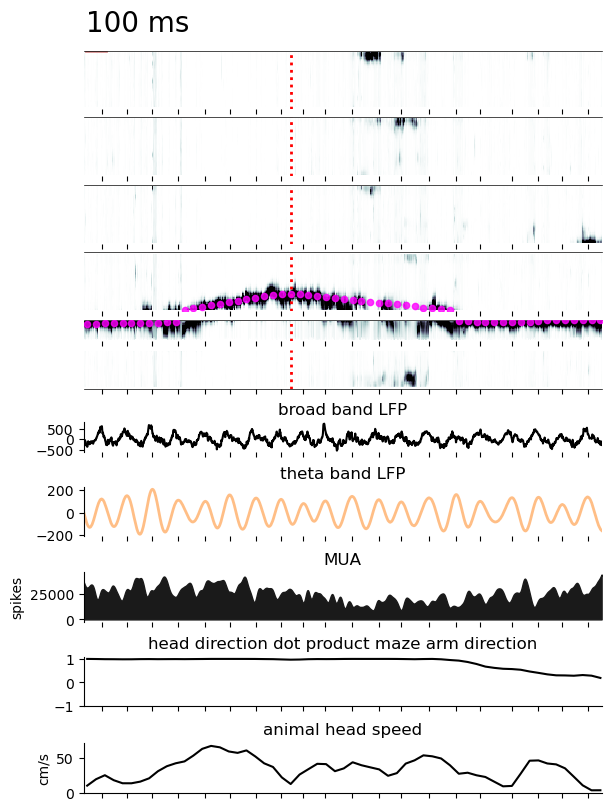

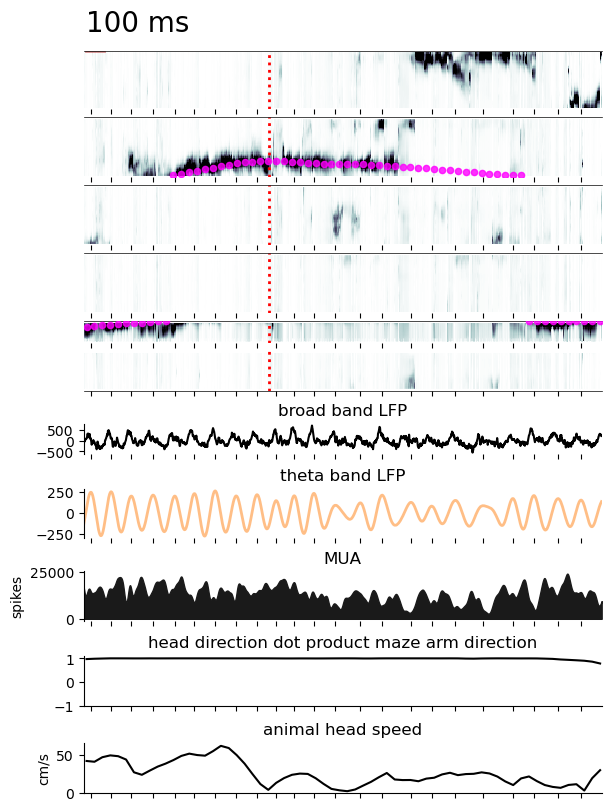

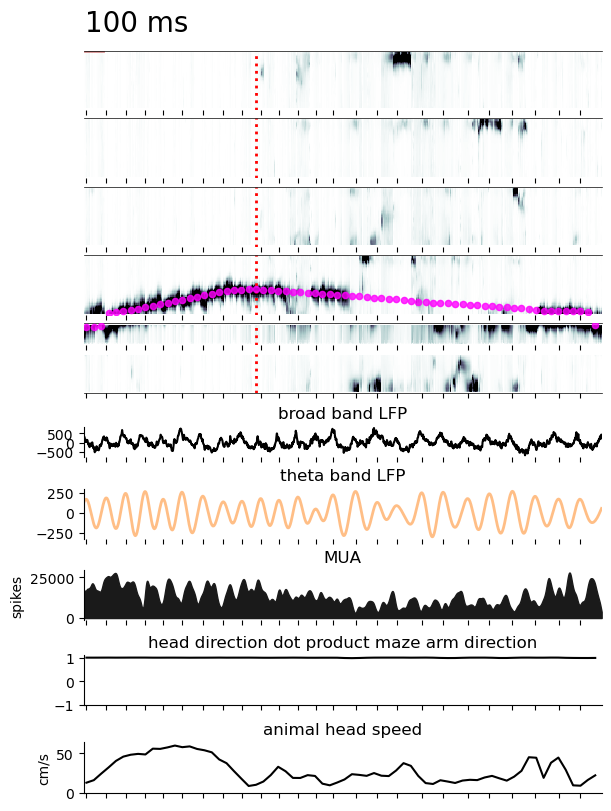

In [21]:
figure_folder = "/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/"
draw_intervals = False

for example in examples_short:
    nwb_copy_file_name, epoch_num, session_name, t, ind, (tx, ty), type_long, arm = example
    animal = nwb_copy_file_name[:5]
    if type_long:
        prefix = "longdata"
    else:
        prefix = "data"
    if animal == "lewis":
        datafield = "leftside"
    else:
        datafield = "rightside"

    for param in [param2]:#params:
        variant = param["variant"]
        plot_data_filename = f"{prefix}_variant{variant}_{animal}_{nwb_copy_file_name}_{session_name}_trial{t}.pkl"

        try:
            output_path = os.path.join(output_folder,plot_data_filename)
            with open(output_path, 'rb') as file:
                data = pickle.load(file)
            print(f"Data loaded from {output_path}")
        except:
            print(f"Problem with {nwb_copy_file_name, epoch_num, session_name}")
            continue

        mua_smoothened = smoothen_mua(data["mua_subset"], moving_ave_window = 0.02) # 20 ms window smoothened
        if theta_type == 'mua':
            theta_subset = get_theta_from_mua(mua_smoothened, 0)
        elif theta_type == 'cc':
            print("loading cc theta")
            
            theta_subset = get_theta_from_cc(nwb_copy_file_name, session_name, datafield = datafield)
            theta_subset = select_subset_helper(theta_subset, data["plottimes"])
            print("finished cc theta")

        #### find theta intervals
        if draw_intervals:
            local_extended_theta_interval, remote_theta_interval = return_theta_intervals(nwb_copy_file_name,
                                                                                      epoch_num, session_name, t)
        else:
            local_extended_theta_interval, remote_theta_interval = None, None

        print("plotting")
        t0t1= data["plottimes"]
        plot_decode_spiking(t0t1,data["linear_position_subset"],data["decode"],theta_subset,
                        data["lfp_subset"], mua_smoothened, data["head_speed_subset"],
                        savefolder=data["output_folder"], savename=figure_folder+plot_data_filename+theta_type,
                        t0 = data["t0"], plot_len = 6,
                        turnaround = np.array([data["t0"]-0.03,data["t0"]+0.03]).reshape((1,-1)),likelihood = False,
                        rightward = data["rightward"],
                        location_size = 20,
                        head_direction = data["head_direction"], vmin = 0, vmax = 0.06,
                        local_extended_theta_interval = local_extended_theta_interval,
                        remote_theta_interval = remote_theta_interval)

## End here

In [53]:
data["plottimes"]

[1691517694.117429, 1691517699.117429]

In [28]:
output_path = os.path.join(output_folder,plot_data_filename)
with open(output_path, 'rb') as file:
    data = pickle.load(file)
print(f"Data loaded from {output_path}")

NameError: name 'pickle' is not defined

In [1]:
theta_subset

NameError: name 'theta_subset' is not defined

In [58]:
#theta_test = theta_subset.to_array()

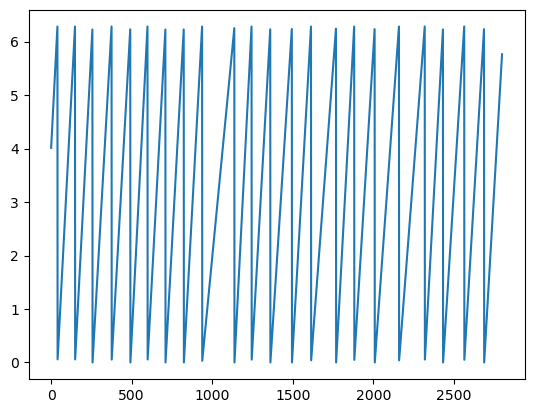

In [430]:
from spyglass.shijiegu.Analysis_SGU import get_linearization_map
from spyglass.shijiegu.changeOfMind_remote_location import region, center_region
from spyglass.shijiegu.changeOfMind_figures.example_snippet import decode_by_regions

In [431]:
decode_input = data["decode"]

In [432]:
positions, decode_outs, axes_ind = decode_by_regions(decode_input, region)

In [433]:
lengths = [len(pos) for pos in positions][::-1]

In [445]:
positions[0]

array([ 0.99377522,  2.98132565,  4.96887608,  6.95642651,  8.94397694,
       10.93152737, 12.91907781, 14.90662824, 16.89417867, 18.8817291 ,
       20.86927953, 22.85682996, 24.8443804 , 26.83193083, 28.81948126,
       30.80703169, 32.79458212, 34.78213255, 36.76968298, 38.75723342,
       40.74478385, 42.73233428, 44.71988471, 46.70743514, 48.69498557,
       50.68253601, 52.67008644, 54.65763687, 56.6451873 ])

In [435]:
#decode_out.position

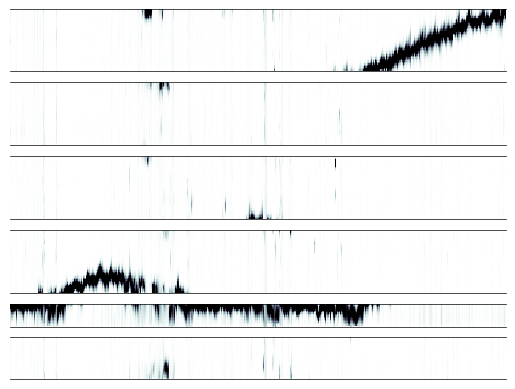

In [436]:
fig, axes = plt.subplots(6, 1, gridspec_kw={"height_ratios": lengths},sharey = False)
    
for ind in range(6):
    ax_ind = axes_ind[ind]
    decode_out = decode_outs[ind]
    
    decode_out.plot(
              x='time', y='position', ax=axes[ax_ind],vmin = 0, vmax = 0.06,
              rasterized=True, cmap='bone_r',infer_intervals = False,
              add_colorbar=False, add_labels=False)
    axes[ax_ind].set_xticks([])
    axes[ax_ind].set_yticks([])
    axes[ax_ind].set_xlabel("")
    axes[ax_ind].set_ylabel("")

    axes[ax_ind].spines['top'].set_linewidth(0.5)
    axes[ax_ind].spines['right'].set_visible(False)
    # Keep the left and bottom borders visible
    axes[ax_ind].spines['left'].set_visible(False)
    axes[ax_ind].spines['bottom'].set_linewidth(0.5)

    position_bins = positions[ind]
    axes[ax_ind].set_ylim([position_bins[0],position_bins[-1]])

In [391]:
sub_gs

GridSpecFromSubplotSpec(6, 1)

In [201]:
decode_out.T.shape

(204, 400)

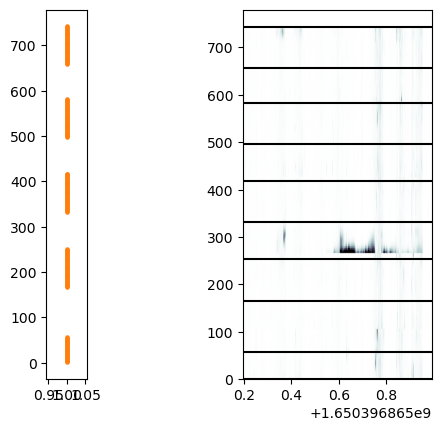

In [204]:
fig, axes = plt.subplots(1, 2, gridspec_kw={"width_ratios": [1,10]},sharey = False)
# decode_out.plot(
#              x='time', y='position', ax=axes[1],vmax = 0.06,
#              rasterized=True, robust=True, cmap='bone_r',infer_intervals = False)

y = np.array(decode_out.position)
axes[0].scatter(np.ones_like(y),y,s=5,color = 'C1')
for segment in region:
    start_end = region[segment]
    axes[1].axhline(start_end[0],color = 'k')
    axes[1].axhline(start_end[1],color = 'k')

[10:35:08][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


array([1.29396953, 1.29110162, 1.2882076 , ..., 1.27982604, 1.28366961,
       1.28752466])